In [1]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [17]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets,
    inspect_sound_with_repetition,
)

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from IPython.display import HTML
audio_style = "<style>audio { margin-left: 23px; width: 720px; }</style>"
display(HTML(audio_style))

### Query examples from Freesound

In [20]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [44]:
FREESOUND_API_KEY = os.getenv('FREESOUND_API_KEY')
FREESOUND_API_KEY = FREESOUND_API_KEY.strip('"')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [45]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [173]:
# Query for THIS RUN
query = '"4 times"'
filt = "duration:[0 TO 15] onset_count:[3 TO 12]"
num_results = 20

In [174]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = query_freesound(
        query=query,
        filter=filt,
        client=client,
        fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
        num_results=num_results,
)


print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
subdir_path = AUDIO_DIR + query.replace(" ", "-")
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, subdir_path)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, subdir_path)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "query": query,
    "subdir_path": subdir_path
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 722979
[2/20] Downloading sound ID 708308
[3/20] Downloading sound ID 511552
[4/20] Downloading sound ID 527742
[5/20] Downloading sound ID 527739
[6/20] Downloading sound ID 684114
[7/20] Downloading sound ID 324603
[8/20] Downloading sound ID 567757
[9/20] Downloading sound ID 442972
[10/20] Downloading sound ID 448077
[11/20] Downloading sound ID 371551
[12/20] Downloading sound ID 394863
[13/20] Downloading sound ID 484800
[14/20] Downloading sound ID 43209
[15/20] Downloading sound ID 20716
[16/20] Downloading sound ID 60698
[17/20] Downloading sound ID 166740
[18/20] Downloading sound ID 232657
[19/20] Downloading sound ID 157780
[20/20] Downloading sound ID 149462
Saved metadata CSV: ../data/meta/dataset_2026-05-18_14-55-05.csv
Saved query log JSON: ../data/meta/dataset_2026-05-18_14-55-05.json


In [175]:
!ls ../data/meta

dataset_2026-05-18_14-55-05.csv  dataset_2026-05-18_14-55-05.json


In [176]:
!ls ../data/audio

'"4-times"'


In [221]:
delete_dataset_with_gc(META_DIR + "dataset_2026-05-18_14-55-05.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-05-18_14-55-05.csv
Deleted query file: /workspace/data/meta/dataset_2026-05-18_14-55-05.json
Deleted audio: /workspace/data/audio/"4-times"/722979_15435613-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/527739_11653850-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/371551_1265752-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/684114_907124-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/448077_5781159-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/527742_11653850-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/20716_104634-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/567757_907124-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/511552_1676145-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/708308_15362740-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/394863_3597414-hq.ogg
Deleted audio: /workspace/data/audio/"4-times"/324603_2465261-hq.ogg
Deleted audio: /worksp

### Show downloaded audio

In [14]:
!ls -lt ../data/audio/'"4-times"'

ls: cannot access '../data/audio/"4-times"': No such file or directory


In [14]:
# select a file manually
filename = "66113_877451-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/66113_877451-hq.ogg'

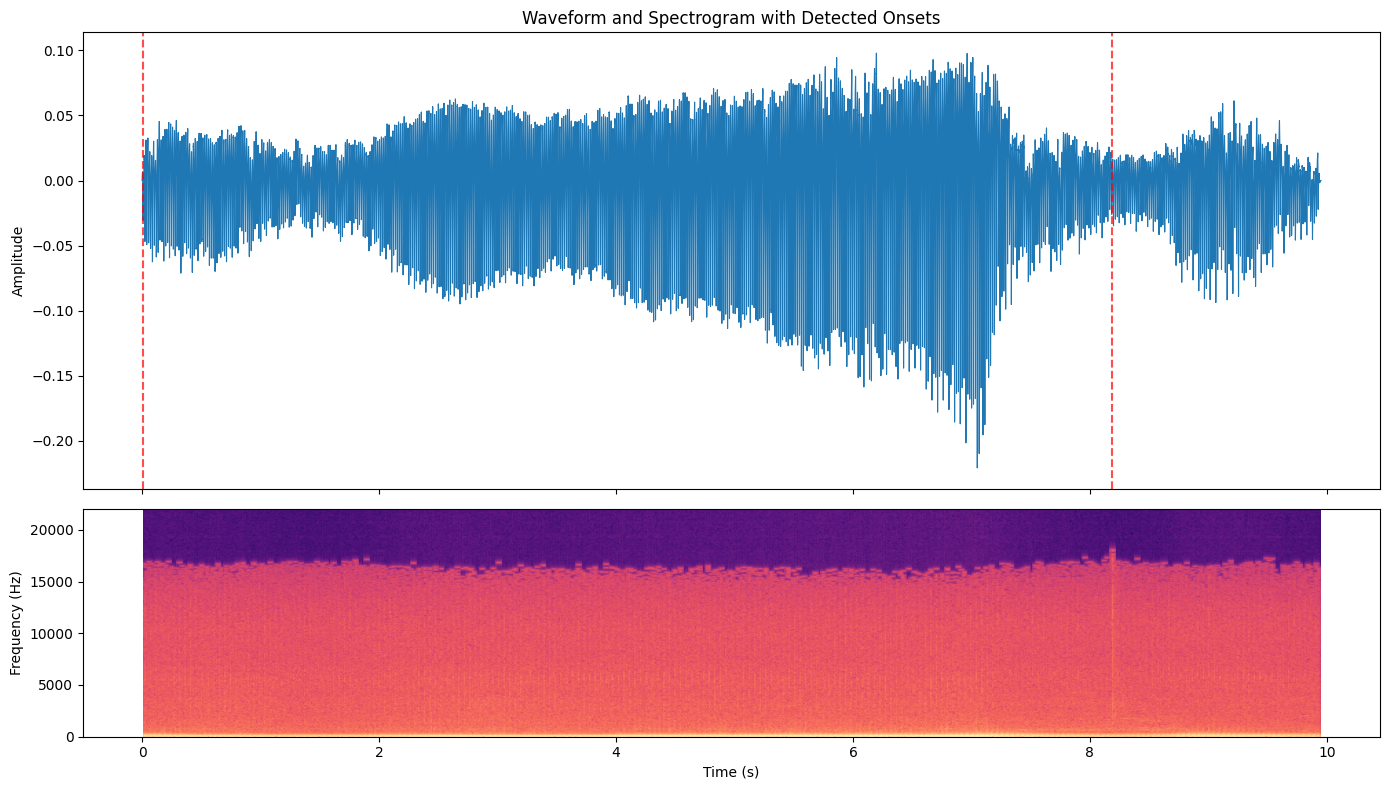

In [15]:
# select a file randomly
subdir = 'electric-fan'
filename = random.choice(os.listdir(AUDIO_DIR + subdir))
filepath = f"{AUDIO_DIR}/{subdir}/{filename}"
sound_id = int(filename[:filename.find("_")])

start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filepath)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)

### Analyze repetitiveness

In [100]:
!ls ../data/audio

'"3-times"'  '"4-times"'


In [177]:
subdir = '"4-times"'

In [178]:
filenames = os.listdir(f'{AUDIO_DIR}/{subdir}')
freesound_ids = [int(filename[:filename.find("_")]) for filename in filenames]

In [219]:
current_id = freesound_ids[19]

--- Analyzing: 157780_2847644-hq.ogg ---
Total raw onsets detected: 15
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 157780 ---
File: 157780_2847644-hq.ogg
Method: Freesound Native (es.OnsetRate) | Detected: 15 | In Pattern: 0


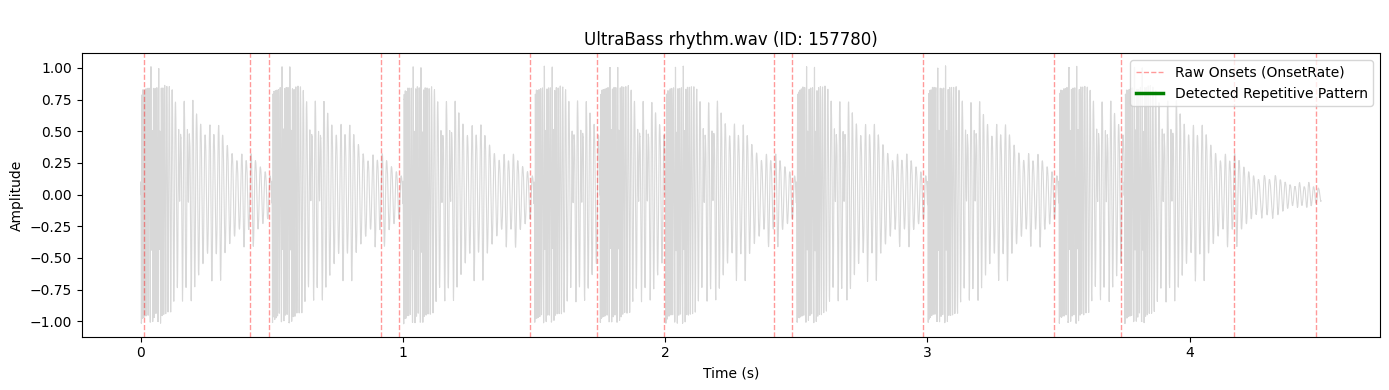

In [220]:
inspect_sound_with_repetition(META_DIR, current_id)

---

### GARBAGE

In [ ]:
import os
import glob
import json
import pandas as pd
from IPython.display import display, Audio

def _build_query_map(meta_dir):
    """Internal helper to map query strings to sets of unique Freesound IDs."""
    query_to_ids = {}
    global_unique_ids = set()
    
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        json_path = csv_path.rsplit(".", 1)[0] + ".json"
        
        # Fallback to filename
        query_str = os.path.basename(csv_path) 
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    if "queries" in data and isinstance(data["queries"], list):
                        # NORMALIZATION 1: Strip whitespace from every query
                        q_list = [q.get("query", "").strip() for q in data["queries"]]
                        query_str = " + ".join(filter(None, q_list)) 
            except Exception:
                pass
                
        df = pd.read_csv(csv_path)
        if "sound_id" in df.columns:
            # NORMALIZATION 2: Use lowercase keys for internal storage
            lookup_key = query_str.lower()
            
            if lookup_key not in query_to_ids:
                # We store the 'display_name' so the table still looks nice
                query_to_ids[lookup_key] = {"display_name": query_str, "ids": set()}
            
            unique_in_csv = df["sound_id"].unique()
            query_to_ids[lookup_key]["ids"].update(unique_in_csv)
            global_unique_ids.update(unique_in_csv)
            
    return query_to_ids, global_unique_ids

# ---------------------------------------------------------
def summarize_queries(meta_dir):
    query_map, global_unique = _build_query_map(meta_dir)
    
    print(f"{'Query String':<45} | {'Unique Sounds'}")
    print("-" * 65)
    
    # Sort by the display name
    for key in sorted(query_map.keys()):
        item = query_map[key]
        print(f"{item['display_name']:<45} | {len(item['ids'])}")
        
    print("-" * 65)
    print(f"{'TOTAL ABSOLUTE UNIQUE SOUNDS':<45} | {len(global_unique)}")

# ---------------------------------------------------------
# 2. Get IDs for a Specific Query
# ---------------------------------------------------------
def print_ids_for_query(meta_dir, target_query):
    """Given a query string, prints all associated Freesound IDs beautifully."""
    query_map, _ = _build_query_map(meta_dir)
    search_key = target_query.strip().lower()
    
    if search_key in query_map:
        item = query_map[search_key]
        
        # 1. Cast to int to remove the 'np.int64' branding
        # 2. Sort them so the list isn't jumping around randomly
        clean_ids = sorted([int(sid) for sid in item["ids"]])
        
        print(f"--- {item['display_name'].upper()} ({len(clean_ids)} sounds) ---")
        
        for sid in clean_ids:
            print(sid)
            
        return clean_ids
    else:
        print(f"Query '{target_query}' not found.")
        available = [v['display_name'] for v in query_map.values()]
        print(f"Available options: {available}")
        return []

# ---------------------------------------------------------
# 3. Inspect, Plot, and Play a Specific Sound ID
# ---------------------------------------------------------
def inspect_sound(meta_dir, sound_id):
    """
    Looks up a Freesound ID, prints metadata, plots the waveform/spectrogram 
    with onsets, and displays a playable audio widget.
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        df = pd.read_csv(csv_path)
        
        if "sound_id" in df.columns:
            match = df[df["sound_id"] == sound_id]
            
            if not match.empty:
                row = match.iloc[0]
                local_path = row["local_path"]
                
                print(f"--- Sound ID: {sound_id} ---")
                print(f"Name: {row.get('name', 'N/A')}")
                print(f"Tags: {row.get('tags', 'N/A')}")
                print(f"Path: {local_path}\n")
                
                if not os.path.exists(local_path):
                    print("Error: Audio file not found on disk. Run ensure_datasets_audio().")
                    return
                
                # Run onset detection
                audio, onsets = detect_onsets(local_path)
                print(f"Detected {len(onsets)} onsets.")
                
                # Plot
                plot_waveform_with_onsets(audio, onsets)
                
                # Display playback widget
                display(Audio(local_path))
                return
                
    print(f"Sound ID {sound_id} not found in any metadata CSV.")